In [22]:
'''连扳龙头策略,主要用于监控市场情绪'''
%reload_ext autoreload
%autoreload 2
from fun import *
import polars as pl
import pandas as pd
import datetime as dt
import time 


logging = get_logger(log_file='回测.log',inherit=False)

start_date = dt.date(2021,1,1)
end_date = dt.datetime.today()

# 获取指定日期的日线数据
stock_data = read_day_data(start_date=start_date,end_date=end_date,file_path='ts_stock_all_data')
stock_data = stock_data.drop_nulls(subset=['open','close','pre_close','limit_up','limit_down'])
market_value = read_day_data(start_date=start_date,end_date=end_date,file_path='ts_daily_basic')
market_value = market_value.with_columns([
   ( pl.col('free_share')*pl.col('close')/1e4).alias('free_float_mv')
])
stock_data = stock_data.join(market_value.select(['code','trading_date','free_float_mv']),on=['code','trading_date'],how='left')
#stock_data.schema
# 去掉没用的列
stock_data = stock_data.drop(['change','total_share','attack','activity','pe','float_share','buying','selling','swing','strength','avg_turnover'])

In [23]:
# 1.涨停标记
# 标记涨停状态：limit_status
stock_data = mark_limit_status(stock_data)
# 标记涨停描述：limit_desc
stock_data = mark_limit_desc(stock_data)
# 记录最近的一次涨停描述：last_limit_desc
stock_data = mark_last_limit_desc(stock_data)
# 统计10天内涨停平均换手率
stock_data = cal_limit_avg_turnover(stock_data, window=5)
stock_data = cal_limit_avg_turnover(stock_data, window=10)

# 2.均线特征
# 计算均线:sma_{window}
stock_data = add_sma(stock_data, window=5)
stock_data = add_sma(stock_data, window=7)

# 3.计算开盘涨幅:open_chg,乖离率,成交均价vwap
stock_data = stock_data.with_columns(
    (
        (pl.col("open") - pl.col("pre_close")) 
        / pl.col("pre_close") 
        * 100
    ).alias("open_pct"),  # 开盘涨幅百分比
    ((pl.col("close") - pl.col("sma_7")) / pl.col("sma_7") * 100).alias("close_sma7_pct"), #乖离率
    (pl.col("amount")*100 / pl.col("volume")).alias("vwap"),
    ((pl.col("low") <= pl.col("limit_down")*1.01)).alias("touch_limit_down"), # 是否触及跌停
)
stock_data = cal_n_lowest(stock_data)


# 3.k线特征
# 计算量比,k线特征
#stock_data = add_volume_ratio(stock_data, window=5)
#stock_data = cal_kline_pattern_features(stock_data)


# 筛选stock_data行 为买入信号 1. 昨日涨停or断板or炸板   2.今日低开-3%至-4%  3.昨日收盘在昨日日五线上   4. 最近一次涨停描述 !=一天一板 或者 非空
# 1. 先确保数据按股票和日期排序
stock_data = stock_data.sort(["code", "trading_date"])

# 2. 在每个股票组内计算移位数据（关键步骤）
stock_data = stock_data.with_columns([
    # 同一股票内的前一天涨停状态
    pl.col("limit_status").shift(1).over("code").alias("prev_limit_status"),
    # 同一股票内的前一天5日均线
    pl.col("sma_7").shift(1).over("code").alias("prev_sma_7"),
    #pl.col("ema_7").shift(1).over("code").alias("prev_ema_7"),
    #pl.col("volume_ratio_5").shift(1).over("code").alias("pre_volume_ratio_5"),
    pl.col("pct").shift(1).over("code").alias("pre_pct"),
    pl.col("vwap").shift(1).over("code").alias("pre_vwap"),
    #pl.col("ewma_volatility_8").shift(1).over("code").alias("pre_ewma_volatility_8"),
    pl.col("close_sma7_pct").shift(1).over("code").alias("pre_close_sma7_pct"),
    
    # k线特征
    # pl.col("body_ratio").shift(1).over("code").alias("pre_body_ratio"),
    # pl.col("upper_shadow_ratio").shift(1).over("code").alias("pre_upper_shadow_ratio"),
    # pl.col("lower_shadow_ratio").shift(1).over("code").alias("pre_lower_shadow_ratio"),
    # pl.col("candle_direction").shift(1).over("code").alias("pre_candle_direction")
])

# 3. 基于组内移位后的数据筛选买入信号
# 条件参数字典
params_dict={
    'low':5,
    'high':9.5,
    'mv_min':25,
    'mv_max':800,
    'prev_limit_status':['涨停'],
    'avg_limit_turnover_5_min':5,
    'avg_limit_turnover_5_max':50,
}
# 筛选数据并添加signal列
stock_data = stock_data.with_columns(
    # 构建筛选条件表达式
    signal = pl.when(
        # 非st,创业,科创
        ~(pl.col("type").is_not_null() & (pl.col("type") == "ST")) &
        ~(pl.col("code").str.split(".").list[1].str.starts_with("30") | 
          pl.col("code").str.split(".").list[1].str.starts_with("688")) &

        # 1. 昨日涨停情况
        (pl.col("prev_limit_status").is_in(params_dict['prev_limit_status'])) &

        # 2. 开盘
        (pl.col("open_pct") >= params_dict["low"]) & 
        (pl.col("open_pct") <= params_dict["high"]) &

        # 3. 昨日收盘在昨日5日均线上（注意你代码里写的是prev_sma_7，确认是否是笔误）
        (pl.col("pre_close") >= pl.col("prev_sma_7")) &

        # 4. 最近一次涨停描述 != 一天一板 且 非空
        (pl.col("last_limit_desc") != "1天1板") &
        (pl.col("last_limit_desc").is_not_null()) &

        # 5. 自由流通值区间
        (pl.col("free_float_mv") >= params_dict["mv_min"]) & 
        (pl.col("free_float_mv") <= params_dict["mv_max"]) &

        # 6. 最近的涨停平均换手率
        (pl.col("avg_limit_turnover_5") >= params_dict["avg_limit_turnover_5_min"]) &
        (pl.col("avg_limit_turnover_5") <= params_dict["avg_limit_turnover_5_max"]) & #爆量

        # 6. 绝对位置不能太高，不能触发严重异动
        ((pl.col("open")/pl.col("lowest_30")) <= 3)
        
    ).then(1).otherwise(0)
)

# 如果需要只筛选出signal=1的行（可选）
信号文件 = stock_data.filter(pl.col("signal") == 1)

logging.info(f"回测信号参数: {params_dict}")

回测信号参数: {'low': 5, 'high': 9.5, 'mv_min': 25, 'mv_max': 800, 'prev_limit_status': ['涨停'], 'avg_limit_turnover_5_min': 5, 'avg_limit_turnover_5_max': 50}


In [24]:
from trade_fun import *
start_date_str = start_date.strftime("%Y-%m-%d")
end_date_str = end_date.strftime("%Y-%m-%d")
#end_date_str = '2025-11-17'

logging.info(f"回测时间区间: {start_date_str} 至 {end_date_str}")
result_df,merged_df = cal_trade_info(信号文件,trade_fun=trade,start_date=start_date_str,end_date=end_date_str)


回测时间区间: 2021-01-01 至 2026-01-10
使用40个进程并行处理，共656个日期任务
回测任务进度: 100%|███████████████████████| 656/656 [02:26<00:00,  4.47个日期/s]
所有回测任务完成，共处理656个日期的结果


1.33.1


e:\working\anaconda3\envs\quant\lib\functools.py:888: DataOrientationWarning:

Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.

总调整天数: 7, 调整正确率: 41.18%, 预计平均亏损改善: 4.1887%
总调整天数: 133, 调整正确率: 60.20%, 预计平均亏损改善: 4.1289%
回测结果(不风控):

回测时间:2024-01-02 - 2026-01-09
策略胜率: 42.20%
策略盈亏比: 1.13
每日平均开仓个数: 2.00
平均持仓天数: 1.87 天
每单位风险期望收益:-0.0990
策略总收益率: -19.54%
策略年化收益率: -10.19%
最大回撤: -68.36%
最大回撤阶段: 2024-01-02 至 2025-03-27
夏普比率: 0.13
策略超额年化收益率: -27.92%
最终净值: 0.8046


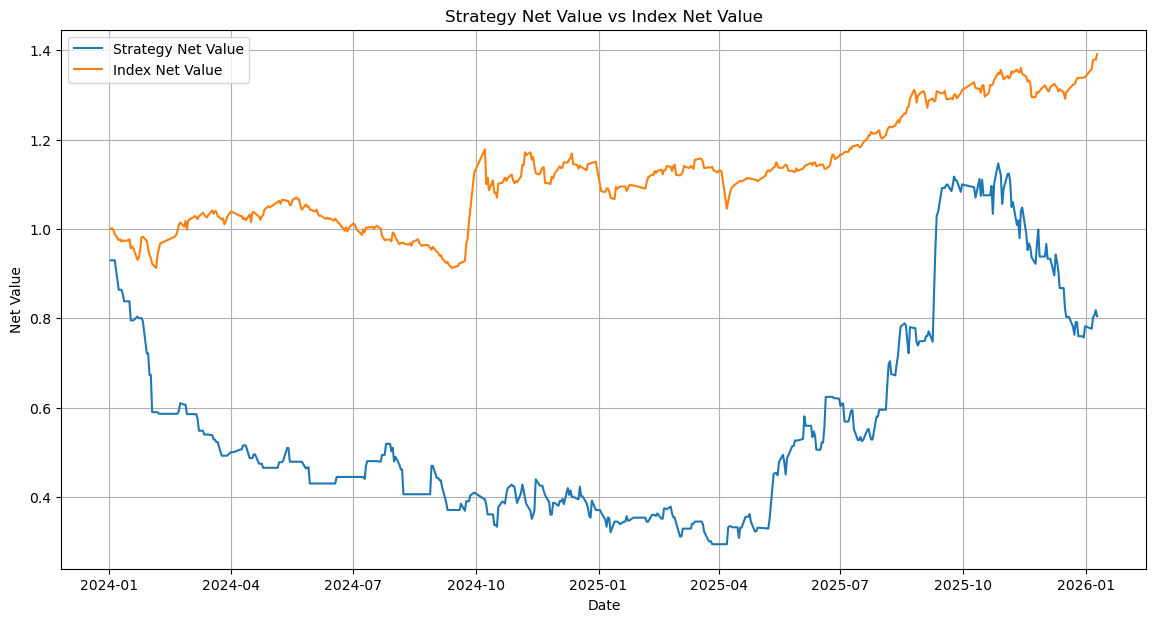

回测结果(触及跌停风控):

回测时间:2024-01-02 - 2026-01-09
策略胜率: 43.17%
策略盈亏比: 1.10
每日平均开仓个数: 2.00
平均持仓天数: 1.87 天
每单位风险期望收益:-0.0942
策略总收益率: 17.75%
策略年化收益率: 8.42%
最大回撤: -49.15%
最大回撤阶段: 2024-01-02 至 2025-03-27
夏普比率: 0.45
策略超额年化收益率: -9.31%
最终净值: 1.1775


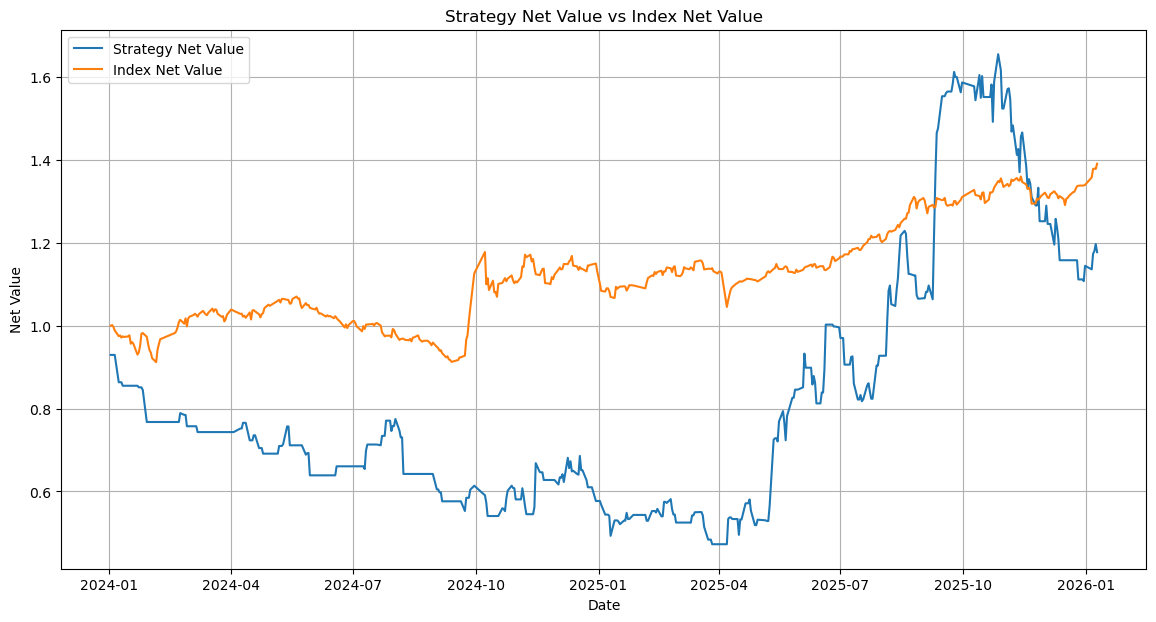

回测结果(买点下移风控):

回测时间:2024-01-02 - 2026-01-09
策略胜率: 43.10%
策略盈亏比: 1.13
每日平均开仓个数: 2.00
平均持仓天数: 1.87 天
每单位风险期望收益:-0.0824
策略总收益率: 3.42%
策略年化收益率: 1.68%
最大回撤: -58.77%
最大回撤阶段: 2024-01-02 至 2025-03-27
夏普比率: 0.34
策略超额年化收益率: -16.05%
最终净值: 1.0342


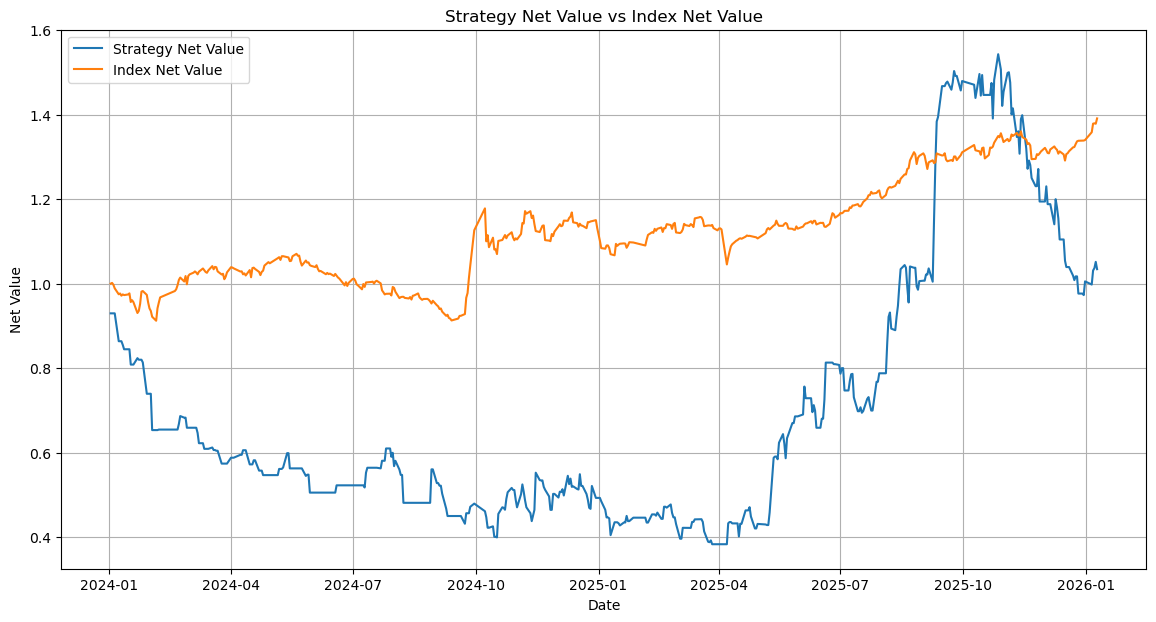

In [25]:
from trade_fun import report_backtest_full
from fun import *
from trade_fun import adjust_weight_by_near_n, adjust_weight_by_consecutive_losses # 触及跌停调仓

# 取sell_date为前n个窗口的股票表现与平均水平进行对比。高于平均水平并且昨日的股票触及跌停达到一定比率，则仓位调整为min_weight

print(pl.__version__)
#print(type(merged_df))
# 构建文件名
filename = f"信号文件/断板低开{params_dict['low']}-{params_dict['high']} {dt.datetime.now().strftime('%Y%m%d_%H%M%S')}(sma7).csv"
# 使用Python的文件操作指定编码
#merged_df.write_csv(filename, include_bom=True)

# 1.仓位控制风控(merged_df_with_weight)
merged_df_with_weight = adjust_weight_by_near_n(merged_df,return_column='weight_touch_limit_down') 
"""触及跌停风控"""
# 2.连续亏损风控
merged_df_with_weight = adjust_weight_by_consecutive_losses(merged_df_with_weight,return_column='weight_consec_loss')
merged_df_with_weight = merged_df_with_weight.with_columns(
    pl.when(pl.col("weight_touch_limit_down") == pl.col("weight_consec_loss")) # 相等时取任意一列的值（结果一致）
    .then(pl.col("weight_touch_limit_down"))  # 相等时取任意一列的值（结果一致）
    .otherwise(pl.min_horizontal("weight_touch_limit_down", "weight_consec_loss"))  # 不等时取最小值
    .alias("weight")
)
merged_df_with_weight = merged_df_with_weight.with_columns(
    (pl.col("profit") * pl.col("weight")).alias("weight_profit")
)
#merged_df_with_weight.write_csv(filename, include_bom=True)

# 买点下移风控(merged_df_with_weight_adjust)
rate_move = 0.02
# 增加买点下移的逻辑（当weight=0时,如果low<=open*(1-rate_move)时,买点下移rate_move（也就是profit+rate_move*100），否则profit=0）
merged_df_with_weight_adjust = merged_df_with_weight.with_columns(
    pl.when(pl.col("weight") != 0)
    # 条件1：weight≠0 → 保持原profit不变
    .then(pl.col("profit"))
    # 条件2：weight==0 → 进一步判断low是否满足下移条件
    .otherwise(
        pl.when(pl.col("low") <= pl.col("open") * (1 - rate_move))
        # 子条件1：满足下移 → profit+rate_move*100
        .then(pl.col("profit") + rate_move * 100)
        # 子条件2：不满足下移 → profit=0
        .otherwise(0)
    ).alias("profit")  # 覆盖原profit列
) #买点下移回测
"""买点下移风控"""
merged_df_with_weight_adjust = merged_df_with_weight_adjust.with_columns(
    (pl.col("profit") *0.4).alias("weight_profit")
)

merged_df = merged_df.with_columns((pl.col("profit") *0.4).alias("weight_profit"))
result_df['weight_profit'] = result_df['profit'] *0.4


# 回测结果汇报
logging.info("回测结果(不风控):")
back_result =report_backtest_full(merged_df.to_pandas(), start_date = '2024-01-01', end_date=end_date_str,profit_col='weight_profit')
logging.info("回测结果(触及跌停风控):")
back_result =report_backtest_full(merged_df_with_weight.to_pandas(), start_date = '2024-01-01', end_date=end_date_str,profit_col='weight_profit')
logging.info("回测结果(买点下移风控):")
back_result =report_backtest_full(merged_df_with_weight_adjust.to_pandas(), start_date = '2024-01-01', end_date=end_date_str,profit_col='weight_profit')
# 将回测结果保存到日志中
#logging.info("\n" + back_result.to_string(index=False))